In [1]:
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving funnel_events_sample.csv to funnel_events_sample (1).csv


import os

print(os.listdir())

In [4]:
df = pd.read_csv("funnel_events.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'funnel_events.csv'

In [5]:
import os

print(os.listdir())

['.config', 'funnel_events_sample (1).csv', 'funnel_events_sample.csv', 'sample_data']


In [6]:
df = pd.read_csv("funnel_events_sample.csv")

In [7]:
df.head()

,user_id,step,timestamp
0,U106,visited_site,2026-07-20 03:40:00
1,U119,signup_started,2026-07-20 04:04:00
2,U029,visited_site,2026-07-20 04:05:00
3,U019,visited_site,2026-07-20 03:33:00
4,U147,visited_site,2026-07-20 04:07:00


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    542 non-null    object
 1   step       542 non-null    object
 2   timestamp  542 non-null    object
dtypes: object(3)
memory usage: 12.8+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
steps = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

In [11]:
counts = df.groupby("step")["user_id"].nunique()
counts = counts.reindex(steps)

print(counts)

step
visited_site          200
signup_started        150
details_filled         96
email_verified         52
purchase_completed     44
Name: user_id, dtype: int64


In [12]:
result = pd.DataFrame({
    "Stage": counts.index,
    "Users": counts.values
})

result

,Stage,Users
0,visited_site,200
1,signup_started,150
2,details_filled,96
3,email_verified,52
4,purchase_completed,44


In [13]:
result["Conversion Rate (%)"] = (
    result["Users"] / result["Users"].shift(1)
) * 100

result.loc[0, "Conversion Rate (%)"] = 100

In [14]:
result["Drop-off"] = (
    result["Users"].shift(1) - result["Users"]
)

result.loc[0, "Drop-off"] = 0

In [15]:
result["Drop-off (%)"] = (
    result["Drop-off"] / result["Users"].shift(1)
) * 100

result.loc[0, "Drop-off (%)"] = 0

In [16]:
result = result.round(2)

result

,Stage,Users,Conversion Rate (%),Drop-off,Drop-off (%)
0,visited_site,200,100.00,0.0,0.00
1,signup_started,150,75.00,50.0,25.00
2,details_filled,96,64.00,54.0,36.00
3,email_verified,52,54.17,44.0,45.83
4,purchase_completed,44,84.62,8.0,15.38


In [17]:
largest = result.loc[result["Drop-off"].idxmax()]

print("Biggest Funnel Leak")
print(f"Stage: {largest['Stage']}")
print(f"Users Lost: {int(largest['Drop-off'])}")
print(f"Drop-off Percentage: {largest['Drop-off (%)']:.2f}%")

Biggest Funnel Leak
Stage: details_filled
Users Lost: 54
Drop-off Percentage: 36.00%


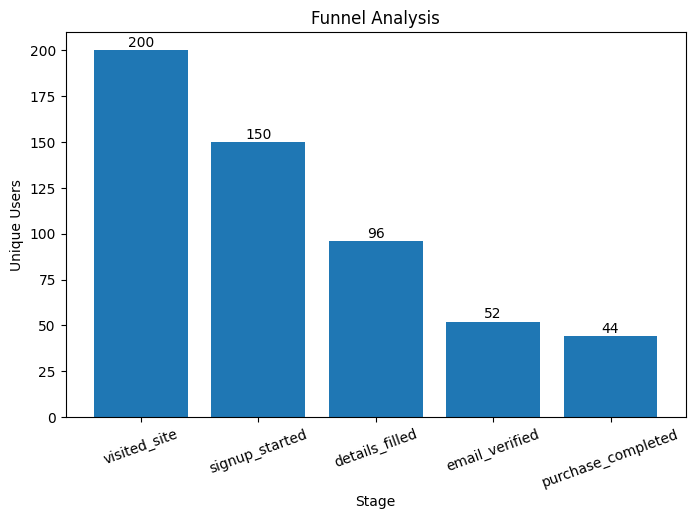

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(result["Stage"], result["Users"])

plt.title("Funnel Analysis")

plt.xlabel("Stage")

plt.ylabel("Unique Users")

plt.xticks(rotation=20)

for i, value in enumerate(result["Users"]):
    plt.text(i, value + 2, str(value), ha='center')

plt.show()

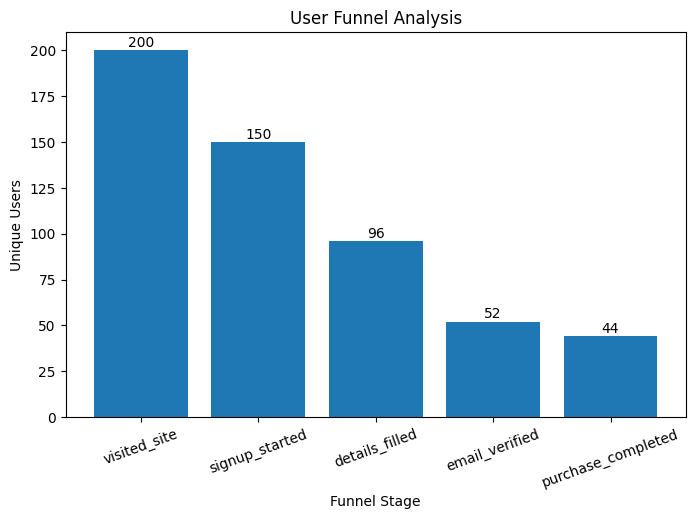

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(result["Stage"], result["Users"])

plt.title("User Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 2,
             str(int(height)),
             ha='center')

plt.show()

In [20]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [21]:
df_unique = (
    df.sort_values("timestamp")
      .drop_duplicates(subset=["user_id", "step"])
)

In [22]:
pivot = df_unique.pivot(
    index="user_id",
    columns="step",
    values="timestamp"
)

In [23]:
pivot.head()

step,details_filled,email_verified,purchase_completed,signup_started,visited_site
user_id,,,,,
U001,2026-07-20 04:35:00,NaT,NaT,2026-07-20 03:52:00,2026-07-20 03:53:00
U002,2026-07-20 04:02:00,NaT,NaT,2026-07-20 03:58:00,2026-07-20 04:09:00
U003,2026-07-20 04:27:00,NaT,NaT,2026-07-20 04:20:00,2026-07-20 04:04:00
U004,2026-07-20 04:25:00,NaT,NaT,2026-07-20 03:54:00,2026-07-20 03:34:00
U005,2026-07-20 04:10:00,NaT,NaT,2026-07-20 03:51:00,2026-07-20 03:43:00


In [24]:
time_summary = []

for i in range(len(steps)-1):
    start = steps[i]
    end = steps[i+1]

    diff = (
        pivot[end] -
        pivot[start]
    ).dropna()

    avg_minutes = diff.mean().total_seconds()/60

    time_summary.append({
        "From": start,
        "To": end,
        "Average Minutes": round(avg_minutes,2)
    })

time_df = pd.DataFrame(time_summary)

time_df

,From,To,Average Minutes
0,visited_site,signup_started,13.48
1,signup_started,details_filled,16.48
2,details_filled,email_verified,NaN
3,email_verified,purchase_completed,NaN


In [25]:
largest = result.loc[result["Drop-off"].idxmax()]

print("="*40)
print("🚨 BIGGEST FUNNEL LEAK")
print("="*40)
print(f"Stage : {largest['Stage']}")
print(f"Users Lost : {int(largest['Drop-off'])}")
print(f"Drop-off : {largest['Drop-off (%)']:.2f}%")

🚨 BIGGEST FUNNEL LEAK
Stage : details_filled
Users Lost : 54
Drop-off : 36.00%


In [26]:
df["Segment"] = df["user_id"].str[-1].astype(int)

df["Segment"] = df["Segment"].apply(
    lambda x: "Even" if x % 2 == 0 else "Odd"
)

In [27]:
segment_counts = (
    df.groupby(["Segment","step"])["user_id"]
      .nunique()
      .unstack()
)

segment_counts

step,details_filled,email_verified,purchase_completed,signup_started,visited_site
Segment,,,,,
Even,48,26,22,75,100
Odd,48,26,22,75,100


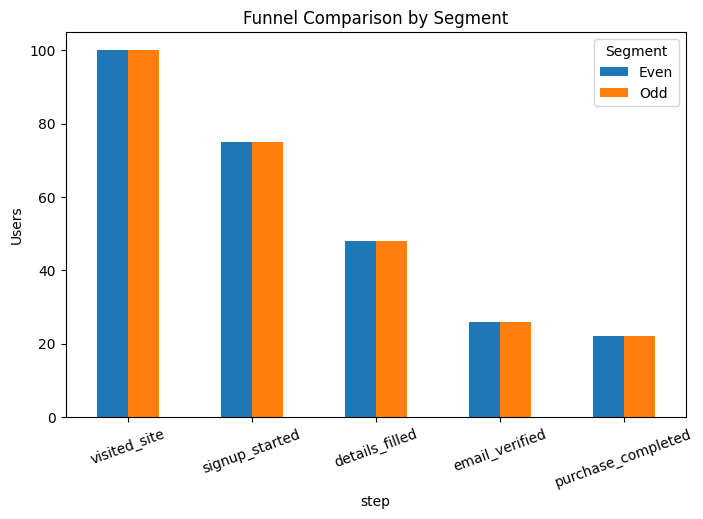

In [28]:
segment_counts = segment_counts.reindex(columns=steps)

segment_counts.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Funnel Comparison by Segment")
plt.ylabel("Users")
plt.xticks(rotation=20)
plt.show()

## Recommendation

The largest drop-off occurs between the **signup_started** and **details_filled** stages, where **54 users (36%)** leave the funnel. This suggests that users may experience friction while filling in their details. Simplifying the form, reducing unnecessary fields, and improving validation messages could increase completion rates and improve overall conversions.